In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [36]:
#Explore data

# Corrected path to match workspace structure
consumption_data = pd.read_csv('../src/paraguay/electricity-consumption-raw.csv')
consumption_data.info()

#grab first 10000 rows
consumption_data = consumption_data.head(10000)

# Further analysis could include checking for missing values, outliers, and seasonal patterns.
max_value = consumption_data['consumption'].max()
min_value = consumption_data['consumption'].min()
mean_value = consumption_data['consumption'].mean()
std_dev = consumption_data['consumption'].std()

#print out all info
print("\n")
print(f"We have the following statistics for electricity consumption:")
print(f"Max Consumption: {max_value}")
print(f"Min Consumption: {min_value}")
print(f"Mean Consumption: {mean_value}")
print(f"Standard Deviation: {std_dev}")


# Check for missing in datetime
missing_values = consumption_data['datetime'].isnull().sum()
print(f"Missing values in 'datetime': {missing_values}")


#Since there is no missing value in datetime we can safely assume that this is a clean ID




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1899312 entries, 0 to 1899311
Data columns (total 4 columns):
 #   Column       Dtype  
---  ------       -----  
 0   datetime     object 
 1   substation   object 
 2   feeder       object 
 3   consumption  float64
dtypes: float64(1), object(3)
memory usage: 58.0+ MB


We have the following statistics for electricity consumption:
Max Consumption: 161.0
Min Consumption: 2.0
Mean Consumption: 65.64273961332785
Standard Deviation: 17.54395862263417
Missing values in 'datetime': 0


# Alternative Time Series Visualization Methods

Here are different ways to visualize time series data, each highlighting different aspects of the data.

Before resampling:
Number of records: 10000
Time range: 2017-01-01 00:00:00 to 2018-02-22 15:00:00
Columns: ['datetime', 'substation', 'feeder', 'consumption']

After daily resampling:
Number of records: 418
Time range: 2017-01-01 00:00:00 to 2018-02-22 00:00:00
Columns: ['datetime', 'consumption']


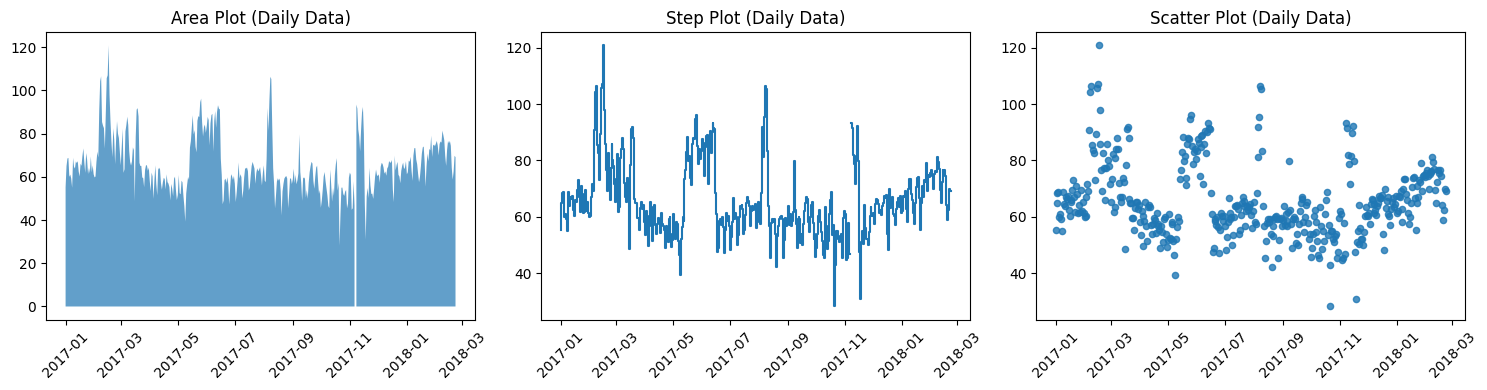

In [37]:
# First, ensure datetime column is properly formatted
consumption_data['datetime'] = pd.to_datetime(consumption_data['datetime'])

# Convert to daily data - RESAMPLING TO DAILY FREQUENCY
print("Before resampling:")
print(f"Number of records: {len(consumption_data)}")
print(f"Time range: {consumption_data['datetime'].min()} to {consumption_data['datetime'].max()}")
print(f"Columns: {list(consumption_data.columns)}")

# Set datetime as index (required for resampling)
consumption_data.set_index('datetime', inplace=True)

# SOLUTION: Only resample numeric columns, handle string columns separately
# Resample to daily frequency using mean aggregation
consumption_daily = consumption_data[['consumption']].resample('D').mean().reset_index()

print("\nAfter daily resampling:")
print(f"Number of records: {len(consumption_daily)}")
print(f"Time range: {consumption_daily['datetime'].min()} to {consumption_daily['datetime'].max()}")
print(f"Columns: {list(consumption_daily.columns)}")

# Use the resampled data for plotting
plot_data = consumption_daily

# 1. AREA PLOT - Shows volume under the curve
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.fill_between(plot_data['datetime'], plot_data['consumption'], alpha=0.7)
plt.title('Area Plot (Daily Data)')
plt.xticks(rotation=45)

# 2. STEP PLOT - Shows discrete changes
plt.subplot(1, 3, 2)
plt.step(plot_data['datetime'], plot_data['consumption'], where='mid')
plt.title('Step Plot (Daily Data)')
plt.xticks(rotation=45)

# 3. SCATTER PLOT - Good for identifying patterns/outliers
plt.subplot(1, 3, 3)
plt.scatter(plot_data['datetime'], plot_data['consumption'], alpha=0.8, s=20)
plt.title('Scatter Plot (Daily Data)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Update consumption_data for use in subsequent cells
consumption_data = consumption_daily

## Different Ways to Resample Time Series to Hourly

You can choose different aggregation methods depending on what makes sense for your data: